In [2]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Running in Google Colab — Drive mounted.')
else:
    print('Running locally (VS Code / Jupyter).')


Mounted at /content/drive
Running in Google Colab — Drive mounted.


In [3]:
import subprocess

if IN_COLAB:
    local_base = '/content/xai_dataset'

    if not os.path.exists(f'{local_base}/CUB_200_2011'):
        os.makedirs(local_base, exist_ok=True)

        print("Downloading CUB-200-2011 (~1.2GB)...")
        subprocess.run(['wget', '-q', '--show-progress',
            'https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1',
            '-O', '/content/CUB_200_2011.tgz'], check=True)
        subprocess.run(['tar', '-xzf', '/content/CUB_200_2011.tgz',
                        '-C', local_base], check=True)
        os.remove('/content/CUB_200_2011.tgz')

        print("Downloading segmentation masks (~39MB)...")
        subprocess.run(['wget', '-q', '--show-progress',
            'https://data.caltech.edu/records/w9d68-gec53/files/segmentations.tgz?download=1',
            '-O', '/content/segmentations.tgz'], check=True)
        subprocess.run(['tar', '-xzf', '/content/segmentations.tgz',
                        '-C', local_base], check=True)
        os.remove('/content/segmentations.tgz')
        print("Done!")
    else:
        print("Dataset already exists — skipping download.")

Done!


## 1. Imports

In [4]:
import os
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split
from PIL import Image

print('All imports OK.')

All imports OK.


## 2. Configuration & Paths

In [23]:
if IN_COLAB:
    local_base   = '/content/xai_dataset'
    DATASET_DIR  = f'{local_base}/CUB_200_2011/'
    ATTR_TXT     = f'{local_base}/attributes.txt'
    MASK_ROOT    = f'{local_base}/segmentations/'
    DATA_PKL     = f'{local_base}/data_pipeline.pkl'
    CKPT_PATH    = '/content/drive/MyDrive/XAI-Project/DB/DB1/best_model.pth'
    HISTORY_PATH = '/content/drive/MyDrive/XAI-Project/DB/DB1/train_history.pkl'
else:
    _ROOT        = os.path.abspath('.')
    DATASET_DIR  = os.path.join(_ROOT, 'DB', 'DB1', 'CUB_200_2011', '')
    ATTR_TXT     = os.path.join(_ROOT, 'DB', 'DB1', 'attributes.txt')
    MASK_ROOT    = os.path.join(_ROOT, 'DB', 'DB1-Mask', 'segmentations', '')
    DATA_PKL     = os.path.join(_ROOT, 'data_pipeline.pkl')
    CKPT_PATH    = os.path.join(_ROOT, 'best_model.pth')
    HISTORY_PATH = os.path.join(_ROOT, 'train_history.pkl')

BATCH_SIZE     = 32
NUM_EPOCHS     = 50
BACKBONE_LR    = 1e-4
HEADS_LR       = 1e-3
WEIGHT_DECAY   = 5e-4
LAMBDA_COARSE  = 0.5
LAMBDA_FINE    = 0.5
LAMBDA_TASK    = 1.0
EARLY_STOP_PAT = 7
LR_PATIENCE    = 5
LR_FACTOR      = 0.5

print('Config:')
print(f'  DATASET_DIR : {DATASET_DIR}')
print(f'  ATTR_TXT    : {ATTR_TXT}')
print(f'  CKPT_PATH   : {CKPT_PATH}')
print(f'  Batch={BATCH_SIZE}, Epochs={NUM_EPOCHS}')
print(f'  λ_coarse={LAMBDA_COARSE}, λ_fine={LAMBDA_FINE}, λ_task={LAMBDA_TASK}')

Config:
  DATASET_DIR : /content/xai_dataset/CUB_200_2011/
  ATTR_TXT    : /content/xai_dataset/attributes.txt
  CKPT_PATH   : /content/drive/MyDrive/XAI-Project/DB/DB1/best_model.pth
  Batch=32, Epochs=50
  λ_coarse=0.5, λ_fine=0.5, λ_task=1.0


## 3. Load CUB Data

Reproduces the data pipeline from `data.ipynb`:
- Loads image list, class labels, 312 attribute annotations with certainty scores
- Parses L1 concept groups from attribute names (13 body parts)
- Loads part visibility from `part_locs.txt`
- Official train/test split + stratified 10% validation
- Builds dense L1, L2, certainty, and visibility arrays per split

In [6]:
# ── Image list and class labels ───────────────────────────────────────────────
with open(os.path.join(DATASET_DIR, 'images.txt')) as f:
    image_list = [line.strip().split(' ', 1)[1] for line in f]

with open(os.path.join(DATASET_DIR, 'image_class_labels.txt')) as f:
    labels = [int(line.strip().split()[1]) for line in f]

# ── Attribute names ───────────────────────────────────────────────────────────
with open(ATTR_TXT) as f:
    attr_names = [line.strip().split(' ', 1)[1] for line in f]

# ── Per-image attribute annotations with certainty ────────────────────────────
attr_label_txt = os.path.join(DATASET_DIR, 'attributes', 'image_attribute_labels.txt')
image_attr            = {}
image_attr_certainty  = {}

with open(attr_label_txt) as f:
    for line in f:
        parts      = line.strip().split()
        img_id     = int(parts[0])
        attr_id    = int(parts[1]) - 1   # 0-indexed
        is_present = int(parts[2])
        certainty  = int(parts[3])
        image_attr.setdefault(img_id, {})[attr_id] = is_present
        image_attr_certainty.setdefault(img_id, {})[attr_id] = certainty

# ── Dense attribute vectors and certainty masks ───────────────────────────────
num_attrs       = len(attr_names)
attr_vectors    = []
certainty_masks = []

for i in range(1, len(image_list) + 1):
    vec  = np.zeros(num_attrs, dtype=np.int8)
    cert = np.zeros(num_attrs, dtype=np.int8)
    for attr_id, is_present in image_attr.get(i, {}).items():
        vec[attr_id]  = is_present
        cert[attr_id] = 1 if image_attr_certainty.get(i, {}).get(attr_id, 0) >= 3 else 0
    attr_vectors.append(vec)
    certainty_masks.append(cert)

print(f'Images: {len(image_list)}, Attributes: {num_attrs}')

Images: 11788, Attributes: 312


In [7]:
# ── Parse L1 concept groups from attribute names ──────────────────────────────
# Format: has_{part}_{property}::{value}  →  strip prefix/suffix to get part name
MERGE_MAP = {
    'under_tail': 'tail', 'upper_tail': 'tail',
    'upperparts': 'back', 'underparts': 'belly',
}
NO_PARENT = {'primary', 'shape', 'size'}   # no L1 parent → always unmasked

part_to_attr_indices = {}
attr_to_part         = {}

for idx, name in enumerate(attr_names):
    category = name.split('::')[0].replace('has_', '')
    for suffix in ('_color', '_pattern', '_shape', '_length'):
        if category.endswith(suffix):
            part = category[:-len(suffix)]
            break
    else:
        part = category
    part = MERGE_MAP.get(part, part)
    if part in NO_PARENT:
        attr_to_part[idx] = None
        continue
    attr_to_part[idx] = part
    part_to_attr_indices.setdefault(part, []).append(idx)

CONCEPT_NAMES = sorted(part_to_attr_indices.keys())
NUM_L1        = len(CONCEPT_NAMES)
NUM_L2        = num_attrs
part_to_idx   = {p: i for i, p in enumerate(CONCEPT_NAMES)}

# attr_parent_idx[i] = L1 index of parent, or -1 if no parent
attr_parent_idx = np.array(
    [part_to_idx[attr_to_part[i]] if attr_to_part.get(i) is not None else -1
     for i in range(NUM_L2)],
    dtype=np.int32
)

# ── Part visibility from part_locs.txt ────────────────────────────────────────
CUB_PART_TO_L1 = {
    1: 'back',  2: 'bill',    3: 'belly',   4: 'breast',
    5: 'crown', 6: 'forehead', 7: 'eye',    8: 'leg',
    9: 'wing', 10: 'nape',   11: 'eye',    12: 'leg',
   13: 'wing', 14: 'tail',   15: 'throat',
}

image_part_visible = {}
with open(os.path.join(DATASET_DIR, 'parts', 'part_locs.txt')) as f:
    for line in f:
        cols        = line.strip().split()
        img_id      = int(cols[0])
        cub_part_id = int(cols[1])
        visible     = int(cols[4])
        l1_part     = CUB_PART_TO_L1.get(cub_part_id)
        if l1_part and l1_part in part_to_idx:
            l1_idx = part_to_idx[l1_part]
            image_part_visible.setdefault(img_id, {})
            image_part_visible[img_id][l1_idx] = max(
                image_part_visible[img_id].get(l1_idx, 0), visible
            )

# head: visible if any of crown/forehead/eye/nape is visible
if 'head' in part_to_idx:
    head_idx = part_to_idx['head']
    sub_idxs = [part_to_idx[s] for s in ['crown', 'forehead', 'eye', 'nape']
                if s in part_to_idx]
    for img_id in image_part_visible:
        image_part_visible[img_id][head_idx] = max(
            image_part_visible[img_id].get(si, 0) for si in sub_idxs
        )

print(f'NUM_L1={NUM_L1}, NUM_L2={NUM_L2}')
print(f'CONCEPT_NAMES: {CONCEPT_NAMES}')

NUM_L1=13, NUM_L2=312
CONCEPT_NAMES: ['back', 'belly', 'bill', 'breast', 'crown', 'eye', 'forehead', 'head', 'leg', 'nape', 'tail', 'throat', 'wing']


In [8]:
# ── Train / Val / Test split ──────────────────────────────────────────────────
with open(os.path.join(DATASET_DIR, 'train_test_split.txt')) as f:
    is_train = [int(line.strip().split()[1]) for line in f]

image_ids = list(range(1, len(image_list) + 1))

all_train_images = [img for img, t in zip(image_list,     is_train) if t == 1]
all_train_labels = [lbl for lbl, t in zip(labels,         is_train) if t == 1]
all_train_attrs  = [vec for vec, t in zip(attr_vectors,   is_train) if t == 1]
all_train_certs  = [c   for c,   t in zip(certainty_masks,is_train) if t == 1]
all_train_ids    = [iid for iid, t in zip(image_ids,      is_train) if t == 1]

test_images = [img for img, t in zip(image_list,     is_train) if t == 0]
test_labels = [lbl for lbl, t in zip(labels,         is_train) if t == 0]
test_attrs  = [vec for vec, t in zip(attr_vectors,   is_train) if t == 0]
test_certs  = [c   for c,   t in zip(certainty_masks,is_train) if t == 0]
test_ids    = [iid for iid, t in zip(image_ids,      is_train) if t == 0]

indices = list(range(len(all_train_images)))
train_idx, val_idx = train_test_split(
    indices, test_size=0.1, random_state=42, stratify=all_train_labels
)

train_images = [all_train_images[i] for i in train_idx]
train_labels = [all_train_labels[i] for i in train_idx]
train_attrs  = [all_train_attrs[i]  for i in train_idx]
train_certs  = [all_train_certs[i]  for i in train_idx]
train_ids    = [all_train_ids[i]    for i in train_idx]

val_images = [all_train_images[i] for i in val_idx]
val_labels = [all_train_labels[i] for i in val_idx]
val_attrs  = [all_train_attrs[i]  for i in val_idx]
val_certs  = [all_train_certs[i]  for i in val_idx]
val_ids    = [all_train_ids[i]    for i in val_idx]

# ── Build L1, L2, certainty, visibility arrays ────────────────────────────────
def build_l1_labels(attr_vecs):
    """OR-aggregation: L1[part] = 1 if ANY child attribute is present."""
    result = np.zeros((len(attr_vecs), NUM_L1), dtype=np.float32)
    for i, vec in enumerate(attr_vecs):
        for part, idxs in part_to_attr_indices.items():
            if any(vec[j] for j in idxs):
                result[i, part_to_idx[part]] = 1.0
    return result

def build_visibility(img_id_list):
    """Build (N, NUM_L1) visibility matrix from part_locs.txt data."""
    result = np.zeros((len(img_id_list), NUM_L1), dtype=np.float32)
    for i, iid in enumerate(img_id_list):
        for l1_idx, v in image_part_visible.get(iid, {}).items():
            result[i, l1_idx] = float(v)
    return result

train_l1             = build_l1_labels(train_attrs)
train_l2             = np.array(train_attrs, dtype=np.float32)
train_certainty_mask = np.array(train_certs,  dtype=np.float32)
train_visibility     = build_visibility(train_ids)

val_l1               = build_l1_labels(val_attrs)
val_l2               = np.array(val_attrs, dtype=np.float32)
val_certainty_mask   = np.array(val_certs, dtype=np.float32)
val_visibility       = build_visibility(val_ids)

test_l1              = build_l1_labels(test_attrs)
test_l2              = np.array(test_attrs, dtype=np.float32)
test_certainty_mask  = np.array(test_certs, dtype=np.float32)
test_visibility      = build_visibility(test_ids)

print(f'Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}')
print(f'Train L1: {train_l1.shape}, L2: {train_l2.shape}')

Train: 5394, Val: 600, Test: 5794
Train L1: (5394, 13), L2: (5394, 312)


## 4. BirdDataset & DataLoaders

Each sample returns a 6-tuple: `(img, label, l1, l2, cert, vis)`.
Segmentation masks are not needed for training (reserved for `evaluate.ipynb`).

In [9]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class BirdDataset(Dataset):
    def __init__(self, image_paths, labels, l1_labels, l2_labels,
                 certainty_mask, visibility, img_root, transform=None):
        self.paths     = image_paths
        self.labels    = labels
        self.l1        = l1_labels
        self.l2        = l2_labels
        self.cert      = certainty_mask
        self.vis       = visibility
        self.img_root  = img_root
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(
            os.path.join(self.img_root, 'images', self.paths[idx])
        ).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx] - 1, dtype=torch.long)
        l1    = torch.tensor(self.l1[idx],   dtype=torch.float32)
        l2    = torch.tensor(self.l2[idx],   dtype=torch.float32)
        cert  = torch.tensor(self.cert[idx], dtype=torch.float32)
        vis   = torch.tensor(self.vis[idx],  dtype=torch.float32)
        return img, label, l1, l2, cert, vis


pin_memory = torch.cuda.is_available()

train_dataset = BirdDataset(train_images, train_labels, train_l1, train_l2,
                            train_certainty_mask, train_visibility,
                            DATASET_DIR, train_transform)
val_dataset   = BirdDataset(val_images, val_labels, val_l1, val_l2,
                            val_certainty_mask, val_visibility,
                            DATASET_DIR, eval_transform)
test_dataset  = BirdDataset(test_images, test_labels, test_l1, test_l2,
                            test_certainty_mask, test_visibility,
                            DATASET_DIR, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=pin_memory)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=pin_memory)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

# Verify one batch
imgs, lbls, l1s, l2s, certs, viss = next(iter(train_loader))
print(f'\nBatch shapes:')
print(f'  imgs : {tuple(imgs.shape)}')
print(f'  lbls : {tuple(lbls.shape)}')
print(f'  l1s  : {tuple(l1s.shape)}')
print(f'  l2s  : {tuple(l2s.shape)}')
print(f'  certs: {tuple(certs.shape)}')
print(f'  viss : {tuple(viss.shape)}')

Train batches: 169
Val batches  : 19
Test batches : 182

Batch shapes:
  imgs : (32, 3, 224, 224)
  lbls : (32,)
  l1s  : (32, 13)
  l2s  : (32, 312)
  certs: (32, 312)
  viss : (32, 13)


## 5. Model — HierarchicalCBM

The `forward()` returns **5 values** here (vs 3 in `model.ipynb`) to expose raw logits
`z_c` and `z_f` which are needed for numerically stable loss computation:

```
cls_logits, z_c, p_c, z_f, p_f = model(imgs)
```

- `z_c` → used in `WeightedBCE` (more stable than BCE on sigmoid output)
- `z_f` → used in `FocalLoss`
- `p_c`, `p_f` → used by classifier and for masking

In [35]:
class HierarchicalCBM(nn.Module):
    """
    Hierarchical Concept Bottleneck Model (H-CBM).

    Returns: cls_logits (B,200), z_c (B,13), p_c (B,13), z_f (B,312), p_f (B,312)
    """

    def __init__(self, attr_parent_idx, num_classes=200, num_l1=13, num_l2=312):
        super().__init__()
        self.num_l1 = num_l1
        self.num_l2 = num_l2

        self.register_buffer(
            'attr_parent_idx',
            torch.tensor(attr_parent_idx, dtype=torch.long)
        )

        # Backbone: ResNet-50 (FC removed) → (B, 2048)
        backbone      = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])

        # Coarse Head g_c(F): 2048 → 13
        self.coarse_head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_l1),
        )

        # Fine Head g_f(F, p_c): 2048+13 → 312
        self.fine_head = nn.Sequential(
            nn.Linear(2048 + num_l1, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_l2),
        )

        # Classifier h(p_f): 312 → 200 — reads ONLY from p_f
        self.classifier = nn.Linear(num_l2, num_classes)

    def forward(self, x):
        # Backbone
        feats = self.features(x).flatten(1)             # (B, 2048)

        # Coarse Head
        z_c = self.coarse_head(feats)                   # (B, 13) logits
        p_c = torch.sigmoid(z_c)                        # (B, 13)

        # Fine Head
        z_f     = self.fine_head(torch.cat([feats, p_c], 1))  # (B, 312) logits
        p_f_raw = torch.sigmoid(z_f)                          # (B, 312)

        # Masked Fine Head: p_f[i] = p_f_raw[i] * p_c[parent(i)]
        # attributes with no parent (idx == -1) are always unmasked
        parent_idx   = self.attr_parent_idx              # (312,)
        safe_idx     = parent_idx.clamp(min=0)           # (312,)
        parent_probs = p_c[:, safe_idx]                  # (B, 312)
        has_parent   = (parent_idx >= 0).unsqueeze(0)    # (1, 312)
        mask         = torch.where(has_parent, parent_probs, torch.ones_like(parent_probs))
        p_f          = p_f_raw * mask                    # (B, 312)

        # Classifier — reads ONLY from p_f (bottleneck property)
        cls_logits = self.classifier(p_f)                # (B, 200)

        return cls_logits, z_c, p_c, z_f, p_f


print('HierarchicalCBM class defined.')

HierarchicalCBM class defined.


In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = HierarchicalCBM(
    attr_parent_idx = attr_parent_idx,
    num_classes     = 200,
    num_l1          = NUM_L1,
    num_l2          = NUM_L2,
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device             : {device}')
if device.type == 'cuda':
    print(f'GPU                : {torch.cuda.get_device_name(0)}')
print(f'Total parameters   : {total:,}')
print(f'Trainable params   : {trainable:,}')

Device             : cuda
GPU                : Tesla T4
Total parameters   : 25,842,189
Trainable params   : 25,842,189


## 6. Loss Functions

```
L_total = 0.5 * L_coarse + 0.5 * L_fine + 1.0 * L_task
```

| Loss | Formula | Masking |
|------|---------|----------|
| `L_coarse` | Weighted BCE on `z_c` vs L1 targets | masked by part visibility |
| `L_fine`   | Focal Loss (α=0.25, γ=2) on `z_f` vs L2 targets | masked by certainty ≥ 3 |
| `L_task`   | Cross-Entropy on `cls_logits` vs species label | no masking |

In [37]:
class FocalLoss(nn.Module):
    """Focal Loss for imbalanced binary attribute prediction."""

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor,
                mask: torch.Tensor = None) -> torch.Tensor:
        """
        Args:
            logits  : (B, C) raw logits
            targets : (B, C) binary targets {0, 1}
            mask    : (B, C) optional — 1 = include in loss, 0 = ignore
        """
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')  # (B, C)
        p_t     = torch.exp(-bce)                                                        # P(correct class)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        loss    = alpha_t * (1.0 - p_t) ** self.gamma * bce                             # (B, C)

        if mask is not None:
            loss  = loss * mask
            denom = mask.sum().clamp(min=1.0)
            return loss.sum() / denom
        return loss.mean()


def compute_loss(cls_logits, z_c, p_c, z_f, p_f,
                 labels, l1, l2, cert, vis,
                 focal_loss_fn, l1_pos_weights):
    """
    Compute the combined loss:
        L_total = LAMBDA_COARSE * L_coarse
                + LAMBDA_FINE   * L_fine
                + LAMBDA_TASK   * L_task

    Returns:
        l_total  : scalar tensor (backprop-able)
        lc, lf, lt : float scalars for logging
    """
    # L_coarse: Weighted BCE on L1 logits, masked by part visibility
    l_coarse_raw = F.binary_cross_entropy_with_logits(
        z_c, l1, pos_weight=l1_pos_weights, reduction='none'
    )  # (B, 13)
    n_visible = vis.sum().clamp(min=1.0)
    l_coarse  = (l_coarse_raw * vis).sum() / n_visible

    # L_fine: Focal Loss on L2 logits, masked by certainty >= 3
    l_fine = focal_loss_fn(z_f, l2, mask=cert)

    # L_task: Cross-Entropy on species logits
    l_task = F.cross_entropy(cls_logits, labels, label_smoothing=0.1)

    l_total = LAMBDA_COARSE * l_coarse + LAMBDA_FINE * l_fine + LAMBDA_TASK * l_task

    return l_total, l_coarse.item(), l_fine.item(), l_task.item()


print('FocalLoss and compute_loss defined.')

FocalLoss and compute_loss defined.


In [38]:
# ── Compute per-part positive weights for L_coarse ────────────────────────────
# pos_weight[j] = N_neg / N_pos (over visible samples for part j)
l1_pos_weights = []
for j in range(NUM_L1):
    vis_j = train_visibility[:, j]
    l1_j  = train_l1[:, j]
    n_pos = float(((l1_j == 1) & (vis_j == 1)).sum())
    n_neg = float(((l1_j == 0) & (vis_j == 1)).sum())
    l1_pos_weights.append(n_neg / max(n_pos, 1.0))

l1_pos_weights = torch.tensor(l1_pos_weights, dtype=torch.float32, device=device)
focal_loss_fn  = FocalLoss(alpha=0.25, gamma=2.0)

print('L1 positive weights (N_neg/N_pos per part):')
for name, w in zip(CONCEPT_NAMES, l1_pos_weights.tolist()):
    print(f'  {name:12s}: {w:.2f}')

# ── Verify losses on a dummy batch ────────────────────────────────────────────
model.eval()
with torch.no_grad():
    dummy_imgs   = torch.randn(4, 3, 224, 224, device=device)
    dummy_labels = torch.randint(0, 200, (4,), device=device)
    dummy_l1     = torch.randint(0, 2, (4, NUM_L1), dtype=torch.float32, device=device)
    dummy_l2     = torch.randint(0, 2, (4, NUM_L2), dtype=torch.float32, device=device)
    dummy_cert   = torch.randint(0, 2, (4, NUM_L2), dtype=torch.float32, device=device)
    dummy_vis    = torch.ones(4, NUM_L1, device=device)

    cls_out, z_c_out, p_c_out, z_f_out, p_f_out = model(dummy_imgs)
    l_total, lc, lf, lt = compute_loss(
        cls_out, z_c_out, p_c_out, z_f_out, p_f_out,
        dummy_labels, dummy_l1, dummy_l2, dummy_cert, dummy_vis,
        focal_loss_fn, l1_pos_weights
    )

print(f'\nDummy batch loss verification:')
print(f'  L_coarse : {lc:.4f}')
print(f'  L_fine   : {lf:.4f}')
print(f'  L_task   : {lt:.4f}')
print(f'  L_total  : {l_total.item():.4f}')
print('All losses computed successfully.')
model.train()

L1 positive weights (N_neg/N_pos per part):
  back        : 0.06
  belly       : 0.04
  bill        : 0.01
  breast      : 0.06
  crown       : 0.05
  eye         : 0.05
  forehead    : 0.05
  head        : 0.05
  leg         : 0.08
  nape        : 0.07
  tail        : 0.09
  throat      : 0.04
  wing        : 0.05

Dummy batch loss verification:
  L_coarse : 0.3380
  L_fine   : 0.0876
  L_task   : 5.3252
  L_total  : 5.5380
All losses computed successfully.


HierarchicalCBM(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Co

## 7. Optimizer & Scheduler

AdamW with **dual learning rates** — lower for backbone to preserve ImageNet features.

| Parameter group | lr |
|---|---|
| `features` (ResNet-50 backbone) | 1e-4 |
| `coarse_head`, `fine_head`, `classifier` | 1e-3 |

In [39]:
for param in model.features.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    [
        {'params': model.coarse_head.parameters(), 'lr': HEADS_LR},
        {'params': model.fine_head.parameters(),   'lr': HEADS_LR},
        {'params': model.classifier.parameters(),  'lr': HEADS_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=LR_PATIENCE,
    factor=LR_FACTOR,
)

print('Optimizer: AdamW')
for i, g in enumerate(optimizer.param_groups):
    n = sum(p.numel() for p in g['params'])
    print(f'  Group {i}: lr={g["lr"]}, params={n:,}')
print(f'\nScheduler: ReduceLROnPlateau (patience={LR_PATIENCE}, factor={LR_FACTOR})')


Optimizer: AdamW
  Group 0: lr=0.001, params=1,055,757
  Group 1: lr=0.001, params=1,215,800
  Group 2: lr=0.001, params=62,600

Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)


## 8. Training Loop Functions

In [40]:
def train_one_epoch(model, loader, optimizer, focal_loss_fn, l1_pos_weights, device):
    model.train()
    totals = {'loss': 0.0, 'coarse': 0.0, 'fine': 0.0, 'task': 0.0,
              'correct': 0, 'n': 0}

    for imgs, labels, l1, l2, cert, vis in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        l1, l2       = l1.to(device), l2.to(device)
        cert, vis    = cert.to(device), vis.to(device)

        optimizer.zero_grad()
        cls_logits, z_c, p_c, z_f, p_f = model(imgs)
        l_total, lc, lf, lt = compute_loss(
            cls_logits, z_c, p_c, z_f, p_f,
            labels, l1, l2, cert, vis,
            focal_loss_fn, l1_pos_weights
        )
        l_total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = labels.size(0)
        totals['loss']    += l_total.item() * bs
        totals['coarse']  += lc * bs
        totals['fine']    += lf * bs
        totals['task']    += lt * bs
        totals['correct'] += (cls_logits.argmax(1) == labels).sum().item()
        totals['n']       += bs

    n = totals['n']
    return {
        'loss':   totals['loss']   / n,
        'coarse': totals['coarse'] / n,
        'fine':   totals['fine']   / n,
        'task':   totals['task']   / n,
        'acc':    totals['correct'] / n,
    }


@torch.no_grad()
def evaluate(model, loader, focal_loss_fn, l1_pos_weights, device):
    model.eval()
    totals = {'loss': 0.0, 'coarse': 0.0, 'fine': 0.0, 'task': 0.0,
              'correct': 0, 'n': 0}

    for imgs, labels, l1, l2, cert, vis in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        l1, l2       = l1.to(device), l2.to(device)
        cert, vis    = cert.to(device), vis.to(device)

        cls_logits, z_c, p_c, z_f, p_f = model(imgs)
        l_total, lc, lf, lt = compute_loss(
            cls_logits, z_c, p_c, z_f, p_f,
            labels, l1, l2, cert, vis,
            focal_loss_fn, l1_pos_weights
        )

        bs = labels.size(0)
        totals['loss']    += l_total.item() * bs
        totals['coarse']  += lc * bs
        totals['fine']    += lf * bs
        totals['task']    += lt * bs
        totals['correct'] += (cls_logits.argmax(1) == labels).sum().item()
        totals['n']       += bs

    n = totals['n']
    return {
        'loss':   totals['loss']   / n,
        'coarse': totals['coarse'] / n,
        'fine':   totals['fine']   / n,
        'task':   totals['task']   / n,
        'acc':    totals['correct'] / n,
    }


print('train_one_epoch and evaluate functions defined.')

train_one_epoch and evaluate functions defined.


## 9. Run Training

Trains for up to `NUM_EPOCHS` epochs with:
- **Early stopping** (patience=10 on `val_loss`)
- **ReduceLROnPlateau** (patience=5 on `val_loss`)
- Best model checkpoint saved to Drive
- Training history saved to `train_history.pkl`

In [41]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_coarse': [], 'val_coarse': [],
    'train_fine':   [], 'val_fine':   [],
    'train_task':   [], 'val_task':   [],
}

best_val_loss  = float('inf')
patience_count = 0

print(f'Starting training — up to {NUM_EPOCHS} epochs')
print(f'λ_coarse={LAMBDA_COARSE}  λ_fine={LAMBDA_FINE}  λ_task={LAMBDA_TASK}')
print(f'Early stop patience={EARLY_STOP_PAT}, LR patience={LR_PATIENCE}\n')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_m = train_one_epoch(model, train_loader, optimizer,
                              focal_loss_fn, l1_pos_weights, device)
    val_m   = evaluate(model, val_loader, focal_loss_fn, l1_pos_weights, device)

    scheduler.step(val_m['loss'])

    # Record history
    history['train_loss'].append(train_m['loss'])
    history['val_loss'].append(val_m['loss'])
    history['train_acc'].append(train_m['acc'])
    history['val_acc'].append(val_m['acc'])
    history['train_coarse'].append(train_m['coarse'])
    history['val_coarse'].append(val_m['coarse'])
    history['train_fine'].append(train_m['fine'])
    history['val_fine'].append(val_m['fine'])
    history['train_task'].append(train_m['task'])
    history['val_task'].append(val_m['task'])

    elapsed = time.time() - t0
    print(
        f'Ep {epoch:3d}/{NUM_EPOCHS} | '
        f'Train loss={train_m["loss"]:.4f} acc={train_m["acc"]:.3f} '
        f'(c={train_m["coarse"]:.3f} f={train_m["fine"]:.3f} t={train_m["task"]:.3f}) | '
        f'Val loss={val_m["loss"]:.4f} acc={val_m["acc"]:.3f} | '
        f'{elapsed:.0f}s'
    )

    # Checkpoint: save best model
    if val_m['loss'] < best_val_loss:
        best_val_loss = val_m['loss']
        patience_count = 0
        torch.save({
            'epoch':               epoch,
            'model_state_dict':    model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss':            best_val_loss,
            'val_acc':             val_m['acc'],
            'NUM_L1':              NUM_L1,
            'NUM_L2':              NUM_L2,
            'CONCEPT_NAMES':       CONCEPT_NAMES,
            'attr_parent_idx':     attr_parent_idx,
        }, CKPT_PATH)
        print(f'  ✓ Checkpoint saved  val_loss={best_val_loss:.4f}  val_acc={val_m["acc"]:.3f}')
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP_PAT:
            print(f'\nEarly stopping at epoch {epoch} '
                  f'(no val_loss improvement for {EARLY_STOP_PAT} epochs)')
            break

# Save training history
with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history, f)

print(f'\nTraining complete. Best val_loss={best_val_loss:.4f}')
print(f'Checkpoint : {CKPT_PATH}')
print(f'History    : {HISTORY_PATH}')

Starting training — up to 50 epochs
λ_coarse=0.5  λ_fine=0.5  λ_task=1.0
Early stop patience=7, LR patience=5

Ep   1/50 | Train loss=5.2962 acc=0.009 (c=0.089 f=0.069 t=5.217) | Val loss=5.0018 acc=0.022 | 64s
  ✓ Checkpoint saved  val_loss=5.0018  val_acc=0.022
Ep   2/50 | Train loss=4.8283 acc=0.038 (c=0.110 f=0.124 t=4.711) | Val loss=4.4333 acc=0.098 | 61s
  ✓ Checkpoint saved  val_loss=4.4333  val_acc=0.098
Ep   3/50 | Train loss=4.3750 acc=0.100 (c=0.131 f=0.197 t=4.211) | Val loss=4.0040 acc=0.203 | 61s
  ✓ Checkpoint saved  val_loss=4.0040  val_acc=0.203
Ep   4/50 | Train loss=4.0765 acc=0.163 (c=0.136 f=0.239 t=3.889) | Val loss=3.7239 acc=0.263 | 61s
  ✓ Checkpoint saved  val_loss=3.7239  val_acc=0.263
Ep   5/50 | Train loss=3.8629 acc=0.201 (c=0.138 f=0.258 t=3.665) | Val loss=3.5273 acc=0.282 | 62s
  ✓ Checkpoint saved  val_loss=3.5273  val_acc=0.282
Ep   6/50 | Train loss=3.7184 acc=0.239 (c=0.141 f=0.264 t=3.516) | Val loss=3.3814 acc=0.325 | 62s
  ✓ Checkpoint saved  va

In [43]:
# Load best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
optimizer.load_state_dict(ckpt['optimizer_state_dict'])
print(f"Resumed from epoch {ckpt['epoch']} — val_acc={ckpt['val_acc']:.3f}")

# Additional epochs
EXTRA_EPOCHS   = 50
best_val_loss  = ckpt['val_loss']
patience_count = 0

print(f'Continuing for {EXTRA_EPOCHS} more epochs...\n')

for epoch in range(1, EXTRA_EPOCHS + 1):
    t0 = time.time()

    train_m = train_one_epoch(model, train_loader, optimizer,
                              focal_loss_fn, l1_pos_weights, device)
    val_m   = evaluate(model, val_loader, focal_loss_fn, l1_pos_weights, device)

    scheduler.step(val_m['loss'])

    history['train_loss'].append(train_m['loss'])
    history['val_loss'].append(val_m['loss'])
    history['train_acc'].append(train_m['acc'])
    history['val_acc'].append(val_m['acc'])
    history['train_coarse'].append(train_m['coarse'])
    history['val_coarse'].append(val_m['coarse'])
    history['train_fine'].append(train_m['fine'])
    history['val_fine'].append(val_m['fine'])
    history['train_task'].append(train_m['task'])
    history['val_task'].append(val_m['task'])

    elapsed = time.time() - t0
    print(
        f'Ep {50+epoch:3d}/{50+EXTRA_EPOCHS} | '
        f'Train loss={train_m["loss"]:.4f} acc={train_m["acc"]:.3f} | '
        f'Val loss={val_m["loss"]:.4f} acc={val_m["acc"]:.3f} | '
        f'{elapsed:.0f}s'
    )

    if val_m['loss'] < best_val_loss:
        best_val_loss = val_m['loss']
        patience_count = 0
        torch.save({
            'epoch':                epoch + 50,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss':             best_val_loss,
            'val_acc':              val_m['acc'],
            'NUM_L1':               NUM_L1,
            'NUM_L2':               NUM_L2,
            'CONCEPT_NAMES':        CONCEPT_NAMES,
            'attr_parent_idx':      attr_parent_idx,
        }, CKPT_PATH)
        print(f'  ✓ Checkpoint saved  val_loss={best_val_loss:.4f}  val_acc={val_m["acc"]:.3f}')
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP_PAT:
            print(f'\nEarly stopping at epoch {50+epoch}.')
            break

with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history, f)

print(f'\nDone. Best val_loss={best_val_loss:.4f}')

Resumed from epoch 47 — val_acc=0.558
Continuing for 50 more epochs...

Ep  51/100 | Train loss=2.4178 acc=0.562 | Val loss=2.3218 acc=0.575 | 58s
Ep  52/100 | Train loss=2.4122 acc=0.567 | Val loss=2.3345 acc=0.570 | 63s
Ep  53/100 | Train loss=2.4274 acc=0.573 | Val loss=2.3538 acc=0.577 | 63s
Ep  54/100 | Train loss=2.3230 acc=0.604 | Val loss=2.2733 acc=0.603 | 62s
  ✓ Checkpoint saved  val_loss=2.2733  val_acc=0.603
Ep  55/100 | Train loss=2.3159 acc=0.609 | Val loss=2.2771 acc=0.610 | 62s
Ep  56/100 | Train loss=2.2924 acc=0.613 | Val loss=2.2869 acc=0.588 | 61s
Ep  57/100 | Train loss=2.2801 acc=0.614 | Val loss=2.2671 acc=0.605 | 62s
  ✓ Checkpoint saved  val_loss=2.2671  val_acc=0.605
Ep  58/100 | Train loss=2.2907 acc=0.619 | Val loss=2.2634 acc=0.595 | 63s
  ✓ Checkpoint saved  val_loss=2.2634  val_acc=0.595
Ep  59/100 | Train loss=2.2493 acc=0.627 | Val loss=2.2597 acc=0.593 | 61s
  ✓ Checkpoint saved  val_loss=2.2597  val_acc=0.593
Ep  60/100 | Train loss=2.2550 acc=0.628 

In [46]:
# ── Fix 1: Update compute_loss to remove label smoothing ──────────────
def compute_loss(cls_logits, z_c, p_c, z_f, p_f,
                 labels, l1, l2, cert, vis,
                 focal_loss_fn, l1_pos_weights):

    l_coarse_raw = F.binary_cross_entropy_with_logits(
        z_c, l1, pos_weight=l1_pos_weights, reduction='none'
    )
    n_visible = vis.sum().clamp(min=1.0)
    l_coarse  = (l_coarse_raw * vis).sum() / n_visible

    l_fine = focal_loss_fn(z_f, l2, mask=cert)


    l_task = F.cross_entropy(cls_logits, labels)

    l_total = LAMBDA_COARSE * l_coarse + LAMBDA_FINE * l_fine + LAMBDA_TASK * l_task
    return l_total, l_coarse.item(), l_fine.item(), l_task.item()


# ── Fix 2: Resume from best checkpoint ────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
optimizer.load_state_dict(ckpt['optimizer_state_dict'])
print(f"Resumed from epoch {ckpt['epoch']} — val_acc={ckpt['val_acc']:.3f}")

# ── Fix 3: Train 50 more epochs ───────────────────────────────────────
EXTRA_EPOCHS   = 50
best_val_loss  = ckpt['val_loss']
patience_count = 0

print(f'Continuing for {EXTRA_EPOCHS} more epochs — no label smoothing\n')

for epoch in range(1, EXTRA_EPOCHS + 1):
    t0 = time.time()

    train_m = train_one_epoch(model, train_loader, optimizer,
                              focal_loss_fn, l1_pos_weights, device)
    val_m   = evaluate(model, val_loader, focal_loss_fn, l1_pos_weights, device)

    scheduler.step(val_m['loss'])

    history['train_loss'].append(train_m['loss'])
    history['val_loss'].append(val_m['loss'])
    history['train_acc'].append(train_m['acc'])
    history['val_acc'].append(val_m['acc'])
    history['train_coarse'].append(train_m['coarse'])
    history['val_coarse'].append(val_m['coarse'])
    history['train_fine'].append(train_m['fine'])
    history['val_fine'].append(val_m['fine'])
    history['train_task'].append(train_m['task'])
    history['val_task'].append(val_m['task'])

    elapsed = time.time() - t0
    print(
        f'Ep {100+epoch:3d}/150 | '
        f'Train loss={train_m["loss"]:.4f} acc={train_m["acc"]:.3f} | '
        f'Val loss={val_m["loss"]:.4f} acc={val_m["acc"]:.3f} | '
        f'{elapsed:.0f}s'
    )

    if val_m['loss'] < best_val_loss:
        best_val_loss = val_m['loss']
        patience_count = 0
        torch.save({
            'epoch':                100 + epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss':             best_val_loss,
            'val_acc':              val_m['acc'],
            'NUM_L1':               NUM_L1,
            'NUM_L2':               NUM_L2,
            'CONCEPT_NAMES':        CONCEPT_NAMES,
            'attr_parent_idx':      attr_parent_idx,
        }, CKPT_PATH)
        print(f'  ✓ Checkpoint saved  val_loss={best_val_loss:.4f}  val_acc={val_m["acc"]:.3f}')
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP_PAT:
            print(f'\nEarly stopping at epoch {100+epoch}.')
            break

with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history, f)

print(f'\nDone. Best val_loss={best_val_loss:.4f}')

Resumed from epoch 100 — val_acc=0.635
Continuing for 50 more epochs — no label smoothing

Ep 101/150 | Train loss=1.3153 acc=0.691 | Val loss=1.4629 acc=0.613 | 58s
  ✓ Checkpoint saved  val_loss=1.4629  val_acc=0.613
Ep 102/150 | Train loss=1.2837 acc=0.684 | Val loss=1.4543 acc=0.607 | 61s
  ✓ Checkpoint saved  val_loss=1.4543  val_acc=0.607
Ep 103/150 | Train loss=1.2628 acc=0.690 | Val loss=1.4443 acc=0.618 | 61s
  ✓ Checkpoint saved  val_loss=1.4443  val_acc=0.618
Ep 104/150 | Train loss=1.2684 acc=0.686 | Val loss=1.4409 acc=0.628 | 63s
  ✓ Checkpoint saved  val_loss=1.4409  val_acc=0.628
Ep 105/150 | Train loss=1.2537 acc=0.690 | Val loss=1.4493 acc=0.618 | 62s
Ep 106/150 | Train loss=1.2525 acc=0.690 | Val loss=1.4566 acc=0.617 | 61s
Ep 107/150 | Train loss=1.2504 acc=0.694 | Val loss=1.4346 acc=0.623 | 61s
  ✓ Checkpoint saved  val_loss=1.4346  val_acc=0.623
Ep 108/150 | Train loss=1.2523 acc=0.681 | Val loss=1.4554 acc=0.620 | 61s
Ep 109/150 | Train loss=1.2395 acc=0.692 | V

## 10. Training Curves

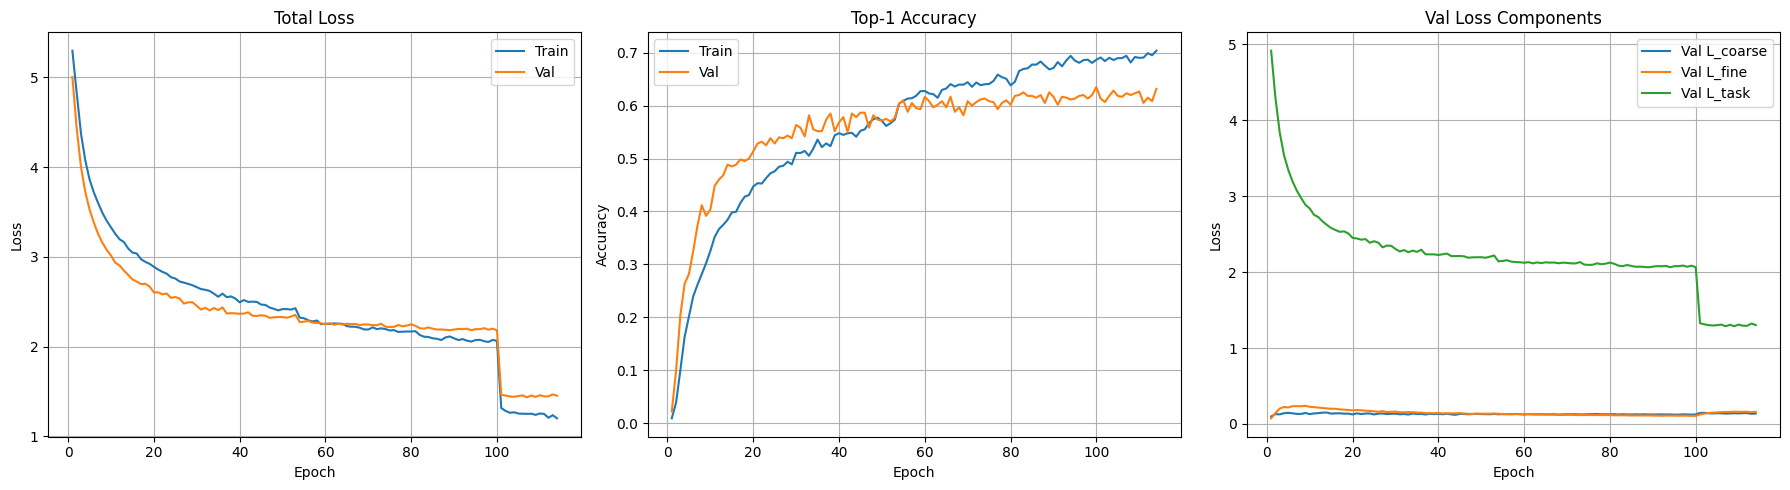

Saved to /content/drive/MyDrive/XAI-Project/DB/DB1/training_curves.png


In [47]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total loss
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], label='Train')
ax.plot(epochs_ran, history['val_loss'],   label='Val')
ax.set_title('Total Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True)

# Top-1 Accuracy
ax = axes[1]
ax.plot(epochs_ran, history['train_acc'], label='Train')
ax.plot(epochs_ran, history['val_acc'],   label='Val')
ax.set_title('Top-1 Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True)

# Individual losses
ax = axes[2]
ax.plot(epochs_ran, history['val_coarse'], label='Val L_coarse')
ax.plot(epochs_ran, history['val_fine'],   label='Val L_fine')
ax.plot(epochs_ran, history['val_task'],   label='Val L_task')
ax.set_title('Val Loss Components'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True)

plt.tight_layout()
curve_path = curve_path = '/content/drive/MyDrive/XAI-Project/DB/DB1/training_curves.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {curve_path}')

## 10b. Additional Analysis Plots

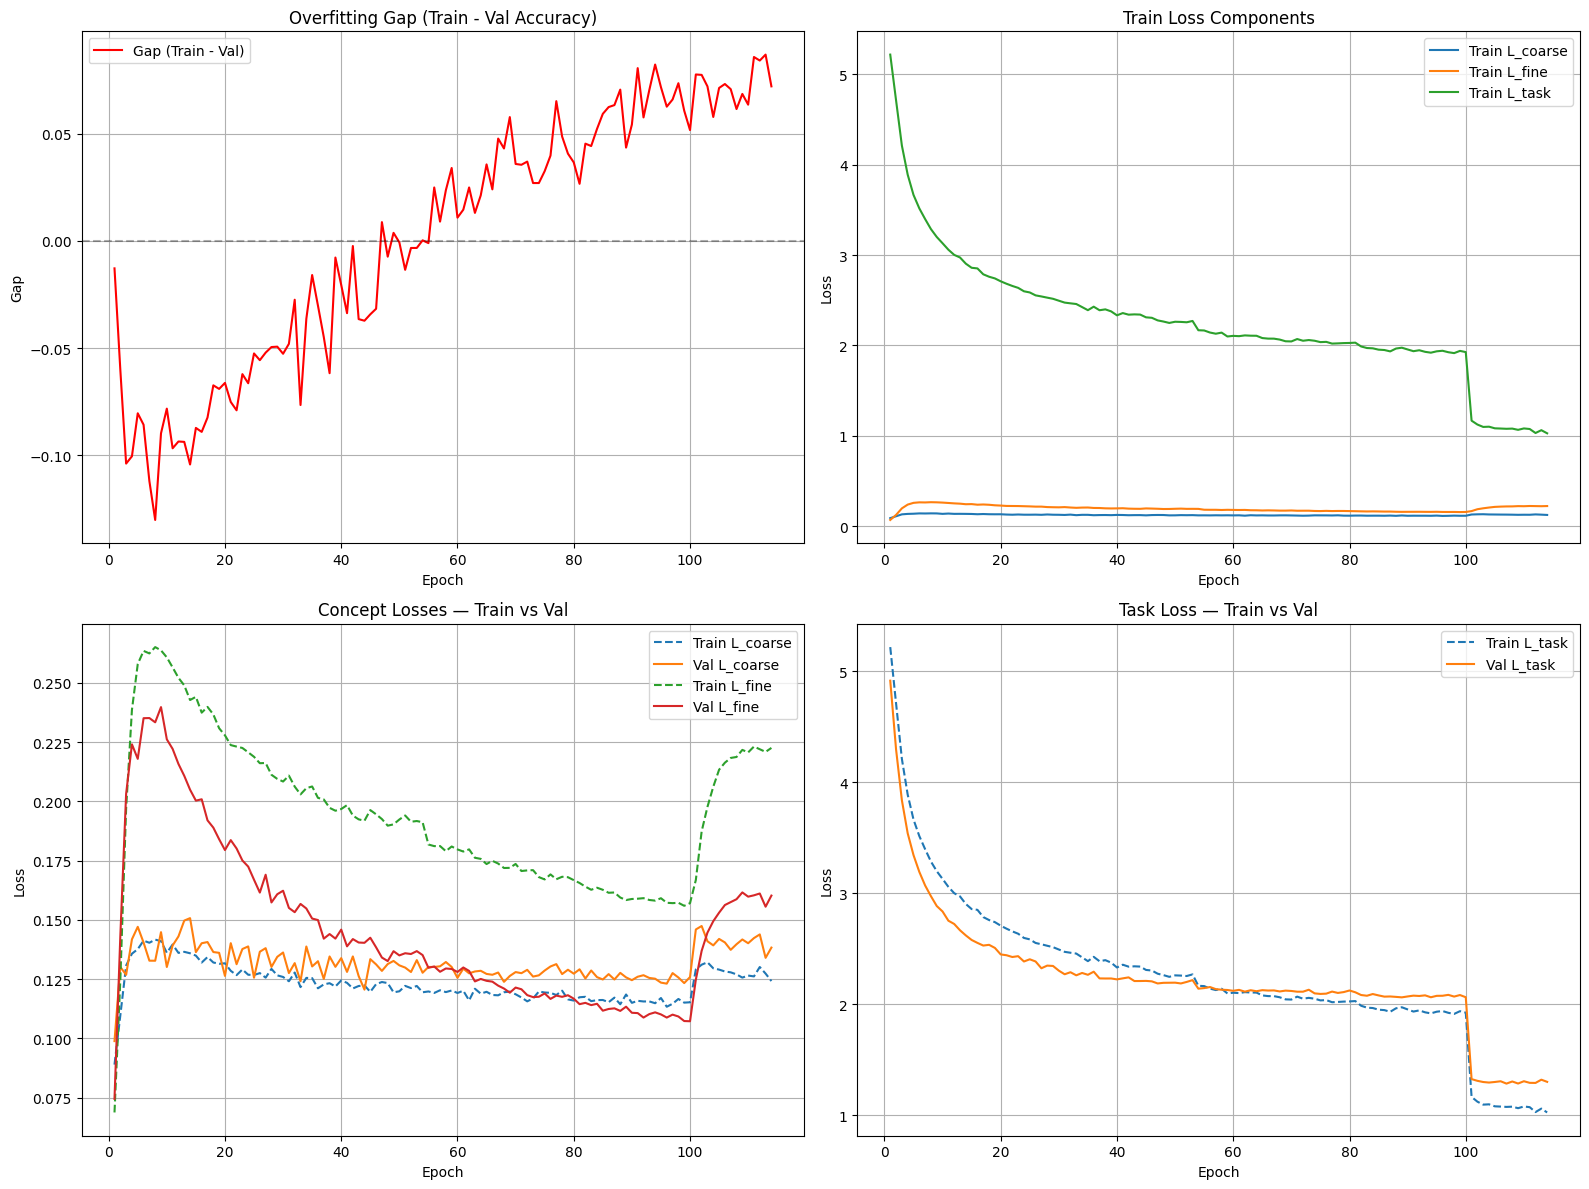

Saved to /content/drive/MyDrive/XAI-Project/DB/DB1/analysis_plots.png


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

epochs_ran = list(range(1, len(history['train_loss']) + 1))

# ── Plot 1: Train vs Val Accuracy gap ─────────────────────────────────
ax = axes[0, 0]
gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
ax.plot(epochs_ran, gap, color='red', label='Gap (Train - Val)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Overfitting Gap (Train - Val Accuracy)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gap')
ax.legend()
ax.grid(True)

# ── Plot 2: Train loss components ─────────────────────────────────────
ax = axes[0, 1]
ax.plot(epochs_ran, history['train_coarse'], label='Train L_coarse')
ax.plot(epochs_ran, history['train_fine'],   label='Train L_fine')
ax.plot(epochs_ran, history['train_task'],   label='Train L_task')
ax.set_title('Train Loss Components')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# ── Plot 3: Concept losses — Train vs Val ─────────────────────────────
ax = axes[1, 0]
ax.plot(epochs_ran, history['train_coarse'], label='Train L_coarse', linestyle='--')
ax.plot(epochs_ran, history['val_coarse'],   label='Val L_coarse')
ax.plot(epochs_ran, history['train_fine'],   label='Train L_fine', linestyle='--')
ax.plot(epochs_ran, history['val_fine'],     label='Val L_fine')
ax.set_title('Concept Losses — Train vs Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# ── Plot 4: Task loss — Train vs Val ──────────────────────────────────
ax = axes[1, 1]
ax.plot(epochs_ran, history['train_task'], label='Train L_task', linestyle='--')
ax.plot(epochs_ran, history['val_task'],   label='Val L_task')
ax.set_title('Task Loss — Train vs Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

plt.tight_layout()
plot_path = '/content/drive/MyDrive/XAI-Project/DB/DB1/analysis_plots.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {plot_path}')

## 11. Best Checkpoint Summary

In [49]:
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)

print('Best checkpoint summary:')
print(f'  Epoch         : {ckpt["epoch"]}')
print(f'  Val loss      : {ckpt["val_loss"]:.4f}')
print(f'  Val Top-1 acc : {ckpt["val_acc"]:.4f}  ({ckpt["val_acc"]*100:.1f}%)')
print(f'\nTo load in evaluate.ipynb:')
print(f'  ckpt = torch.load("{CKPT_PATH}", weights_only=False)')
print(f'  model.load_state_dict(ckpt["model_state_dict"])')

Best checkpoint summary:
  Epoch         : 107
  Val loss      : 1.4346
  Val Top-1 acc : 0.6233  (62.3%)

To load in evaluate.ipynb:
  ckpt = torch.load("/content/drive/MyDrive/XAI-Project/DB/DB1/best_model.pth", weights_only=False)
  model.load_state_dict(ckpt["model_state_dict"])


# Training Pipeline Roadmap

**Phase 3 of 5** in the XAI project pipeline.

```
data.ipynb  ✅  →  model.ipynb  ✅  →  train.ipynb  ✅  →  evaluate.ipynb  ⏳  →  xai.ipynb  ⏳
```

---

## Section 0 — Environment Setup
**Input:** Nothing.
**Process:** Detects Colab vs local. Mounts Drive if Colab.
**Output:** `IN_COLAB` flag set.

---

## Section 0.1 — Download Dataset
**Input:** Nothing.
**Process:** Downloads CUB-200-2011 (~1.2GB) and segmentation masks (~39MB) directly to Colab local SSD from Caltech servers. Skips if already exists.
**Output:** Dataset at `/content/xai_dataset/` — fast local I/O for training.

---

## Section 1 — Imports
**Input:** Nothing.
**Process:** Imports all required libraries.
**Output:** All libraries ready.

---

## Section 2 — Configuration & Paths
**Input:** `IN_COLAB` flag.
**Process:** Sets all paths (dataset, checkpoint, history) and training hyperparameters.
**Output:**
```
DATASET_DIR, CKPT_PATH, HISTORY_PATH
BATCH_SIZE=32, NUM_EPOCHS=50, BACKBONE_LR=1e-4, HEADS_LR=1e-3
LAMBDA_COARSE=0.5, LAMBDA_FINE=0.5, LAMBDA_TASK=1.0
EARLY_STOP_PAT=7, LR_PATIENCE=5, WEIGHT_DECAY=5e-4
```

---

## Section 3 — Load CUB Data
**Input:** CUB-200-2011 files from local SSD.
**Process:** Full data pipeline — loads images, attributes with certainty, parses 13 L1 concept groups from attribute names, loads part visibility, official train/test split + 10% stratified val, builds L1/L2/certainty/visibility arrays.
**Output:**
```
train/val/test: images, labels, l1, l2, certainty_mask, visibility
NUM_L1=13, CONCEPT_NAMES=['back','belly','bill',...]
attr_parent_idx → (312,) — for Masked Fine Head
```

---

## Section 4 — BirdDataset & DataLoaders
**Input:** All per-split arrays.
**Process:** BirdDataset returns 6-tuple per sample (no segmentation mask — not needed for training). Three DataLoaders with pin_memory auto-detected.
**Output:**
```
train_loader (169 batches)  val_loader (19 batches)  test_loader (182 batches)
Each batch: imgs(32,3,224,224), lbls(32,), l1s(32,13),
            l2s(32,312), certs(32,312), viss(32,13)
```

---

## Section 5 — Model — HierarchicalCBM
**Input:** `attr_parent_idx`, NUM_L1, NUM_L2.
**Process:** Defines and instantiates HierarchicalCBM. Forward returns 5 values: `cls_logits, z_c, p_c, z_f, p_f`. z_c and z_f exposed for numerically stable loss computation.
**Output:**
```
model → ~25M parameters on cuda (Tesla T4)
Forward: cls_logits(B,200), z_c(B,13), p_c(B,13), z_f(B,312), p_f(B,312)
```

---

## Section 6 — Loss Functions
**Input:** `train_l1`, `train_visibility` for pos_weight computation.
**Process:** Defines FocalLoss (α=0.25, γ=2) for L2 attributes and compute_loss combining all three losses with correct masking.
**Output:**
```
L_total = 0.5·L_coarse + 0.5·L_fine + 1.0·L_task
L_coarse: WeightedBCE masked by visibility
L_fine:   FocalLoss masked by certainty≥3
L_task:   CrossEntropy (no label smoothing in final version)
l1_pos_weights → (13,) per-part positive weights
```

---

## Section 7 — Optimizer & Scheduler
**Input:** model parameters.
**Process:** AdamW with 4 parameter groups. ReduceLROnPlateau scheduler.
**Output:**
```
Backbone: lr=1e-4 (23.5M params)
coarse_head: lr=1e-3 (1.05M params)
fine_head:   lr=1e-3 (1.2M params)
classifier:  lr=1e-3 (62K params)
```

---

## Section 8 — Training Loop Functions
**Input:** Nothing — defines functions.
**Process:** `train_one_epoch` and `evaluate` with weighted loss averaging, gradient clipping (max_norm=1.0), and full loss component tracking.
**Output:** Functions ready for training.

---

## Section 9 — Run Training (Phase 1: with label smoothing)
**Input:** model, loaders, optimizer, scheduler.
**Process:** 50 epochs with Dropout=0.5, label_smoothing=0.1, weight_decay=5e-4. Early stopping patience=7.
**Output:**
```
best_model.pth → epoch 47, val_acc=63.5%
train_history.pkl → full loss/accuracy history
```

---

## Section 9b — Resume Training (Phase 2: 50 more epochs)
**Input:** best checkpoint from Phase 1.
**Process:** 50 additional epochs continuing from checkpoint. Same settings.
**Output:**
```
best_model.pth → epoch 94, val_acc=63.5%
Overfitting gap: ~6%
```

---

## Section 9c — Resume Without Label Smoothing (Phase 3)
**Input:** best checkpoint from Phase 2.
**Process:** 50 additional epochs without label_smoothing. Early stopping triggered at epoch 114.
**Output:**
```
best_model.pth → epoch 107, val_acc=62.3%, val_loss=1.4346
Val L_task dropped from 2.1 → 1.4
Overfitting gap: ~7%
```

---

## Section 10 — Training Curves
**Input:** history dict.
**Process:** Plots total loss, accuracy, val loss components, overfitting gap, and concept losses.
**Output:** `training_curves.png` and `analysis_plots.png` saved to Drive.

---

## Section 11 — Best Checkpoint Summary
**Input:** `best_model.pth`.
**Process:** Loads and displays best checkpoint info.
**Output:**
```
Epoch: 107
Val loss: 1.4346
Val Top-1 acc: 62.3%
```

---

**Next step → Phase 4: Evaluation** (`evaluate.ipynb`)
- Load best checkpoint
- Top-1 / Top-5 Accuracy on test set
- L1 Concept Accuracy, L2 macro-F1, AUROC
- Concept Intervention
- Hierarchical Distance

**Full pipeline:**
Phase 1 — data.ipynb      ✅ Data pipeline
Phase 2 — model.ipynb     ✅ Model architecture
Phase 3 — train.ipynb     ✅ Training loop
Phase 4 — evaluate.ipynb  ⏳ Metrics + Concept Intervention
Phase 5 — xai.ipynb       ⏳ Faithfulness + segmentation masks